# KNN Classifier

(Implementation from scratch)

In [1]:
import numpy as np 
import seaborn as sns
import pandas as pd
from collections import Counter

In [2]:
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1-x2)**2))

    def predict(self, X_test):
        predictions = []

        for test_point in X_test:
            distances = []
            for train_point in self.X_train:
                distance = self.euclidean_distance(
                    test_point,
                    train_point
                )
                distances.append(distance)

            k_indices = np.argsort(distances)[:self.k]
            k_labels = [
                self.y_train[i]
                for i in k_indices
            ]

            prediction = Counter(k_labels).most_common(1)[0][0]
            predictions.append(prediction)

        return np.array(predictions)

In [3]:
X_train = np.array([
    [170, 60],
    [165, 55],
    [180, 80],
    [175, 75],
    [160, 50]
])


y_train = np.array([
    0,
    0,
    1,
    1,
    0
])

In [4]:
knn = KNN(k=3)

knn.fit(X_train,y_train)

X_test = np.array([
    [172,65]
])

knn.predict(X_test)

array([0])

<Axes: xlabel='x1', ylabel='x2'>

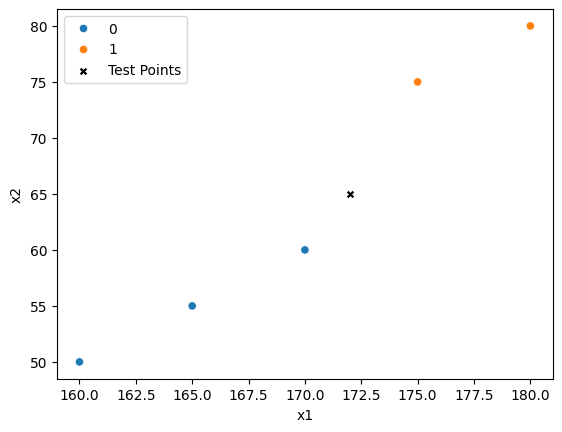

In [5]:
X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train


sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)

X_test_df = pd.DataFrame(X_test, columns=["x1", "x2"]) 

sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    label="Test Points"
)